# Weights & Biases Demo for Linear Regression

This demo shows how to:
1. Set up W&B experiments
2. Run hyperparameter sweeps
3. Compare loss functions (MAE vs MSE)
4. Analyze weight initialization (Zero vs Random)
5. Create parallel coordinate plots
6. Generate a W&B report

Adapt these concepts for your MLP assignment!

In [2]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import argparse

In [3]:
PROJECT_NAME='Linear_regression_demo'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import wandb
import sys
import os

# notebooks/ -> go up one level -> into src/
sys.path.insert(0, os.path.abspath('../src'))

from ann import NeuralNetwork, get_optimizer
from utils import load_dataset, get_batches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

WANDB_PROJECT = "da6401_assignment_1"
WANDB_ENTITY  = None   # replace with your W&B username

print("✅ All imports OK!")

✅ All imports OK!


In [5]:
import importlib
import ann.activations, ann.neural_layer, ann.neural_network, ann
importlib.reload(ann.activations)
importlib.reload(ann.neural_layer)
importlib.reload(ann.neural_network)
importlib.reload(ann)
from ann import NeuralNetwork, get_optimizer
from utils import load_dataset, get_batches
print("✅ Reloaded!")

✅ Reloaded!


In [6]:
def make_model(hidden_size=[128], num_layers=3, activation="relu",
               weight_init="xavier", loss="cross_entropy"):
    """Helper to create NeuralNetwork with cli_args namespace."""
    args = argparse.Namespace(
        hidden_size  = hidden_size,
        num_layers   = num_layers,
        activation   = activation,
        weight_init  = weight_init,
        loss         = loss,
        # required by argparse Namespace but not used in model
        optimizer     = "adam",
        learning_rate = 0.001,
        weight_decay  = 0.0,
        batch_size    = 64,
        epochs        = 10,
        dataset       = "mnist",
        wandb_project = "da6401_assignment_1",
        wandb_entity  = None,
        no_wandb      = True,
        val_split     = 0.1,
        seed          = 42,
        save_dir      = "models",
    )
    return NeuralNetwork(args)

print("✅ make_model helper ready!")

✅ make_model helper ready!


In [8]:
# Fix path so notebook can import from src
import sys
import os

sys.path.insert(0, os.path.abspath('../src'))

# Import dataset loader
from utils.data_loader import load_dataset

# Load MNIST dataset
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset("mnist")

# Verify shapes
print("Dataset Loaded Successfully\n")
print(f"Train : {X_train.shape}  {y_train.shape}")
print(f"Val   : {X_val.shape}    {y_val.shape}")
print(f"Test  : {X_test.shape}   {y_test.shape}")

Dataset Loaded Successfully

Train : (54000, 784)  (54000, 10)
Val   : (6000, 784)    (6000, 10)
Test  : (10000, 784)   (10000, 10)


## Create and Visualize Data

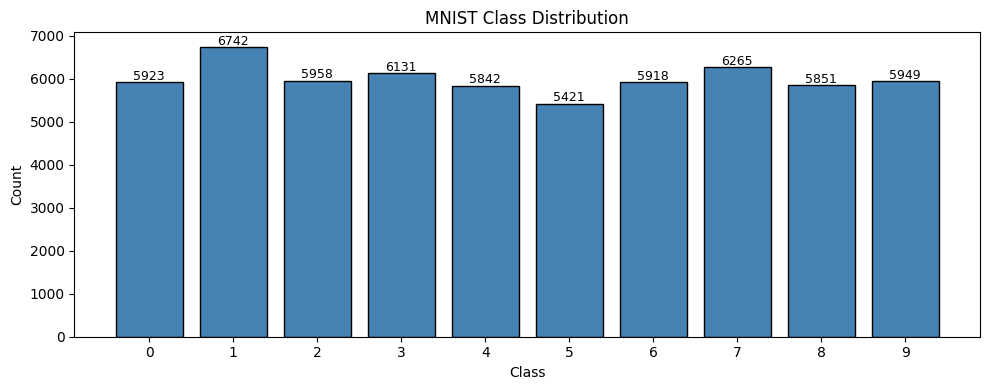

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


✅ Q2.1 done! Check your W&B dashboard.


In [11]:
# Q2.1 - Log 5 sample images from each of the 10 classes

from tensorflow.keras.datasets import mnist
(X_raw, y_raw), _ = mnist.load_data()  # original 28x28 for visualization

CLASS_NAMES = [str(i) for i in range(10)]

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="q2_1_data_exploration")

# ── W&B Table with 5 samples per class ───────────────────────────────────────
table = wandb.Table(columns=["class_id", "class_name", "image"])

for cls in range(10):
    idxs   = np.where(y_raw == cls)[0]
    chosen = np.random.choice(idxs, 5, replace=False)
    for idx in chosen:
        img = wandb.Image(X_raw[idx], caption=f"Class {cls}")
        table.add_data(cls, CLASS_NAMES[cls], img)

wandb.log({"class_samples": table})

# ── class distribution bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
counts  = [np.sum(y_raw == i) for i in range(10)]
ax.bar(CLASS_NAMES, counts, color="steelblue", edgecolor="black")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("MNIST Class Distribution")
for i, c in enumerate(counts):
    ax.text(i, c + 50, str(c), ha="center", fontsize=9)
plt.tight_layout()

wandb.log({"class_distribution": wandb.Image(fig)})
plt.show()

wandb.finish()
print("✅ Q2.1 done! Check your W&B dashboard.")

In [14]:
# Q2.2 - Hyperparameter Sweep (at least 100 runs)
# Run this cell to CREATE the sweep, then run the agent cell below it

sweep_config = {
    "name"   : "mlp_hyperparam_sweep",
    "method" : "bayes",   # Bayesian search finds good configs faster
    "metric" : {
        "name" : "val_acc",
        "goal" : "maximize"
    },
    "parameters" : {
        "epochs"        : {"value"  : 10},
        "batch_size"    : {"values" : [32, 64, 128]},
        "loss"          : {"values" : ["cross_entropy", "mse"]},
        "optimizer"     : {"values" : ["sgd", "momentum", "nag", "rmsprop", "adam", "nadam"]},
        "learning_rate" : {"distribution" : "log_uniform_values", "min" : 0.0001, "max" : 0.1},
        "weight_decay"  : {"values" : [0.0, 0.0005, 0.001]},
        "num_layers"    : {"values" : [2, 3, 4, 5]},
        "hidden_size"   : {"values" : [32, 64, 128]},
        "activation"    : {"values" : ["sigmoid", "tanh", "relu"]},
        "weight_init"   : {"values" : ["random", "xavier"]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print(f"✅ Sweep created! ID: {sweep_id}")

Create sweep with ID: hnreu2or
Sweep URL: https://wandb.ai/da25m017-indian-institute-of-technology-madras/da6401_assignment_1/sweeps/hnreu2or
✅ Sweep created! ID: hnreu2or


In [15]:
# Q2.2 - Run the sweep agent
# This cell runs 100 training experiments automatically

def sweep_train():
    run = wandb.init()
    cfg = run.config

    # resolve hidden sizes
    hidden_sizes = [cfg.hidden_size] * cfg.num_layers

    model = NeuralNetwork(
        input_size   = 784,
        hidden_sizes = hidden_sizes,
        num_classes  = 10,
        activation   = cfg.activation,
        weight_init  = cfg.weight_init,
        loss         = cfg.loss,
    )

    optimizer = get_optimizer(
        cfg.optimizer,
        lr           = cfg.learning_rate,
        weight_decay = cfg.weight_decay,
    )

    for epoch in range(1, cfg.epochs + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in get_batches(X_train, y_train, cfg.batch_size):
            y_pred = model.forward(X_batch)
            epoch_loss += model.compute_loss(y_pred, y_batch, cfg.weight_decay)
            model.backward(y_batch, y_pred, cfg.weight_decay)
            model.update_weights(optimizer)
            n_batches += 1

        train_loss = epoch_loss / n_batches
        train_acc  = model.evaluate(X_train, y_train)
        val_pred   = model.forward(X_val)
        val_loss   = model.compute_loss(val_pred, y_val)
        val_acc    = model.evaluate(X_val, y_val)

        wandb.log({
            "epoch"      : epoch,
            "train_loss" : train_loss,
            "train_acc"  : train_acc,
            "val_loss"   : val_loss,
            "val_acc"    : val_acc,
        })

        print(f"Epoch [{epoch}/{cfg.epochs}] "
              f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    wandb.finish()


# runs 100 experiments — this will take a while!
wandb.agent(sweep_id, function=sweep_train, count=100)
print("✅ Q2.2 Sweep done!")

wandb: Agent Starting Run: cnf7ln3h with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.06536650253873165
wandb: 	loss: mse
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Yaqoob\_netrc.


Epoch [1/10] train_acc=0.1124 val_acc=0.1123
Epoch [2/10] train_acc=0.1124 val_acc=0.1123
Epoch [3/10] train_acc=0.1124 val_acc=0.1123
Epoch [4/10] train_acc=0.1124 val_acc=0.1123
Epoch [5/10] train_acc=0.1124 val_acc=0.1123
Epoch [6/10] train_acc=0.1124 val_acc=0.1123
Epoch [7/10] train_acc=0.1124 val_acc=0.1123
Epoch [8/10] train_acc=0.1124 val_acc=0.1123
Epoch [9/10] train_acc=0.1124 val_acc=0.1123


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch [10/10] train_acc=0.1124 val_acc=0.1123


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▃▃▂▂▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▃▃▂▂▁▁
epoch,10
train_acc,0.11237
train_loss,0.08997
val_acc,0.11233
val_loss,0.08997


...

Epoch [1/10] train_acc=0.9465 val_acc=0.9383
Epoch [2/10] train_acc=0.9594 val_acc=0.9503
Epoch [3/10] train_acc=0.9631 val_acc=0.9507
Epoch [4/10] train_acc=0.9636 val_acc=0.9535
Epoch [5/10] train_acc=0.9683 val_acc=0.9567
Epoch [6/10] train_acc=0.9719 val_acc=0.9593
Epoch [7/10] train_acc=0.9691 val_acc=0.9602
Epoch [8/10] train_acc=0.9670 val_acc=0.9570
Epoch [9/10] train_acc=0.9709 val_acc=0.9597


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch [10/10] train_acc=0.9727 val_acc=0.9627


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▄▅▆▇█▇▆██
train_loss,█▃▂▂▂▁▁▁▁▁
val_acc,▁▄▅▅▆▇▇▆▇█
val_loss,█▅▄▃▃▂▂▃▂▁
epoch,10
train_acc,0.97269
train_loss,0.21568
val_acc,0.96267
val_loss,0.128


✅ Q2.2 Sweep done!


In [14]:
# Q2.3 - Rerun with verified logging
OPTIMIZERS = ["sgd", "momentum", "nag", "rmsprop"]
EPOCHS     = 10

for opt_name in OPTIMIZERS:
    run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = f"q2_3_{opt_name}",
    group   = "optimizer_showdown",
    reinit  = True,
    config  = {
        "optimizer": opt_name,
        "epochs": EPOCHS,
        "batch_size": 64,
        "architecture": "3x128_relu"
        }
    )

    model = make_model(
        hidden_size = [128],
        num_layers  = 3,
        activation  = "relu",
        weight_init = "xavier",
    )

    optimizer = get_optimizer(opt_name, lr=0.001)

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in get_batches(X_train, y_train, 64):
            logits = model.forward(X_batch)
            epoch_loss += model.compute_loss(logits, y_batch)
            model.backward(y_batch, logits)
            model.update_weights(optimizer)
            n_batches += 1

        train_loss = epoch_loss / n_batches
        val_acc    = model.evaluate(X_val, y_val)

        wandb.log({
            "epoch"      : epoch,
            "train_loss" : train_loss,
            "val_acc"    : val_acc,
        }, step=epoch)

        print(f"[{opt_name}] Epoch {epoch}/{EPOCHS}  "
              f"loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    wandb.finish()
    print(f"✅ {opt_name} done!\n")

print("✅ Q2.3 all done!")

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[sgd] Epoch 1/10  loss=2.2270  val_acc=0.3462
[sgd] Epoch 2/10  loss=1.9723  val_acc=0.5695
[sgd] Epoch 3/10  loss=1.5374  val_acc=0.7207
[sgd] Epoch 4/10  loss=1.0773  val_acc=0.7882
[sgd] Epoch 5/10  loss=0.8018  val_acc=0.8210
[sgd] Epoch 6/10  loss=0.6565  val_acc=0.8410
[sgd] Epoch 7/10  loss=0.5706  val_acc=0.8528
[sgd] Epoch 8/10  loss=0.5136  val_acc=0.8662
[sgd] Epoch 9/10  loss=0.4732  val_acc=0.8742
[sgd] Epoch 10/10  loss=0.4427  val_acc=0.8805


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▇▅▃▂▂▂▁▁▁
val_acc,▁▄▆▇▇▇████
epoch,10
train_loss,0.44269
val_acc,0.8805


✅ sgd done!



...

[rmsprop] Epoch 1/10  loss=0.2662  val_acc=0.9607
[rmsprop] Epoch 2/10  loss=0.1096  val_acc=0.9668
[rmsprop] Epoch 3/10  loss=0.0785  val_acc=0.9722
[rmsprop] Epoch 4/10  loss=0.0618  val_acc=0.9733
[rmsprop] Epoch 5/10  loss=0.0507  val_acc=0.9755
[rmsprop] Epoch 6/10  loss=0.0412  val_acc=0.9735
[rmsprop] Epoch 7/10  loss=0.0349  val_acc=0.9758
[rmsprop] Epoch 8/10  loss=0.0296  val_acc=0.9760
[rmsprop] Epoch 9/10  loss=0.0255  val_acc=0.9770


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[rmsprop] Epoch 10/10  loss=0.0221  val_acc=0.9750


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▄▆▆▇▇███▇
epoch,10
train_loss,0.02208
val_acc,0.975


✅ rmsprop done!

✅ Q2.3 all done!


In [9]:
# Q2.4 - Vanishing Gradient Analysis
# Fixed optimizer: RMSProp (updated as per assignment)
# Compare Sigmoid vs ReLU for different network depths

CONFIGS = [
    {"activation": "sigmoid", "hidden_sizes": [128]*5, "name": "sigmoid_5layers"},
    {"activation": "relu",    "hidden_sizes": [128]*5, "name": "relu_5layers"},
    {"activation": "sigmoid", "hidden_sizes": [128]*3, "name": "sigmoid_3layers"},
    {"activation": "relu",    "hidden_sizes": [128]*3, "name": "relu_3layers"},
]

EPOCHS = 10

for cfg in CONFIGS:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f"q2_4_updated_{cfg['name']}",
        group   = "q2_4_vanishing_gradient_updated",
    )

    model = make_model(
        hidden_size = [128],
        num_layers  = len(cfg["hidden_sizes"]),
        activation  = cfg["activation"],
        weight_init = "xavier",
    )

    # fixed optimizer: RMSProp as per assignment
    optimizer = get_optimizer("rmsprop", lr=0.001)

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in get_batches(X_train, y_train, 64):
            logits = model.forward(X_batch)
            epoch_loss += model.compute_loss(logits, y_batch)
            model.backward(y_batch, logits)
            model.update_weights(optimizer)
            n_batches += 1

        # gradient norm of FIRST hidden layer
        grad_norm = float(np.linalg.norm(model.grad_W[0]))
        val_acc   = model.evaluate(X_val, y_val)

        wandb.log({
            "epoch"                : epoch,
            "first_layer_grad_norm": grad_norm,
            "val_acc"              : val_acc,
            "train_loss"           : epoch_loss / n_batches,
        }, step=epoch)

        print(f"[{cfg['name']}] Epoch {epoch}/{EPOCHS}  "
              f"grad_norm={grad_norm:.6f}  val_acc={val_acc:.4f}")

    wandb.finish()

print("Q2.4 done!")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Yaqoob\_netrc.
wandb: Currently logged in as: da25m017 (da25m017-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[sigmoid_5layers] Epoch 1/10  grad_norm=0.439092  val_acc=0.8213
[sigmoid_5layers] Epoch 2/10  grad_norm=0.359161  val_acc=0.9085
[sigmoid_5layers] Epoch 3/10  grad_norm=0.340901  val_acc=0.9358
[sigmoid_5layers] Epoch 4/10  grad_norm=0.473125  val_acc=0.9392
[sigmoid_5layers] Epoch 5/10  grad_norm=0.367535  val_acc=0.9488
[sigmoid_5layers] Epoch 6/10  grad_norm=0.713870  val_acc=0.9267
[sigmoid_5layers] Epoch 7/10  grad_norm=0.356728  val_acc=0.9530
[sigmoid_5layers] Epoch 8/10  grad_norm=0.531564  val_acc=0.9610
[sigmoid_5layers] Epoch 9/10  grad_norm=0.076080  val_acc=0.9630


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[sigmoid_5layers] Epoch 10/10  grad_norm=0.363854  val_acc=0.9597


epoch,▁▂▃▃▄▅▆▆▇█
first_layer_grad_norm,▅▄▄▅▄█▄▆▁▄
train_loss,█▃▂▂▂▁▁▁▁▁
val_acc,▁▅▇▇▇▆████
epoch,10
first_layer_grad_norm,0.36385
train_loss,0.09572
val_acc,0.95967


...

[relu_3layers] Epoch 1/10  grad_norm=1.399468  val_acc=0.9463
[relu_3layers] Epoch 2/10  grad_norm=1.009787  val_acc=0.9695
[relu_3layers] Epoch 3/10  grad_norm=0.728369  val_acc=0.9730
[relu_3layers] Epoch 4/10  grad_norm=1.139182  val_acc=0.9713
[relu_3layers] Epoch 5/10  grad_norm=0.610892  val_acc=0.9705
[relu_3layers] Epoch 6/10  grad_norm=1.220409  val_acc=0.9738
[relu_3layers] Epoch 7/10  grad_norm=1.161380  val_acc=0.9782
[relu_3layers] Epoch 8/10  grad_norm=0.979187  val_acc=0.9755
[relu_3layers] Epoch 9/10  grad_norm=4.103580  val_acc=0.9743


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[relu_3layers] Epoch 10/10  grad_norm=1.000479  val_acc=0.9762


epoch,▁▂▃▃▄▅▆▆▇█
first_layer_grad_norm,▃▂▁▂▁▂▂▂█▂
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▆▇▆▆▇█▇▇█
epoch,10
first_layer_grad_norm,1.00048
train_loss,0.02225
val_acc,0.97617


Q2.4 done!


In [11]:
# Q2.5 - Dead Neuron Investigation
# ReLU with high LR vs Tanh with high LR

CONFIGS = [
    {"activation": "relu", "lr": 0.1, "name": "relu_highlr"},
    {"activation": "tanh", "lr": 0.1, "name": "tanh_highlr"},
]

EPOCHS = 15

for cfg in CONFIGS:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f"q2_5_{cfg['name']}",
        group   = "q2_5_dead_neuron",
    )

    model = make_model(
        hidden_size = [128],
        num_layers  = 3,
        activation  = cfg["activation"],
        weight_init = "xavier",
        loss        = "cross_entropy",
    )

    optimizer = get_optimizer("sgd", lr=cfg["lr"])

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in get_batches(X_train, y_train, 64):
            y_pred = model.forward(X_batch)
            epoch_loss += model.compute_loss(y_pred, y_batch)
            model.backward(y_batch, y_pred)
            model.update_weights(optimizer)
            n_batches += 1

        # ── check dead neurons in all hidden layers ────────────────────────
        # a neuron is "dead" if it outputs 0 for ALL samples in a batch
        dead_fractions = []
        for i, layer in enumerate(model.layers[:-1]):  # skip output layer
            activations  = layer.A                      # (batch, neurons)
            dead_neurons = np.all(activations == 0, axis=0)
            dead_frac    = float(np.mean(dead_neurons))
            dead_fractions.append(dead_frac)

        avg_dead  = float(np.mean(dead_fractions))
        val_acc   = model.evaluate(X_val, y_val)
        grad_norm = float(np.linalg.norm(model.layers[0].grad_W))

        wandb.log({
            "epoch"            : epoch,
            "val_acc"          : val_acc,
            "train_loss"       : epoch_loss / n_batches,
            "avg_dead_neurons" : avg_dead,
            "dead_layer_1"     : dead_fractions[0],
            "dead_layer_2"     : dead_fractions[1],
            "dead_layer_3"     : dead_fractions[2],
            "grad_norm_layer1" : grad_norm,
        }, step=epoch)

        print(f"[{cfg['name']}] Epoch {epoch}/{EPOCHS}  "
              f"val_acc={val_acc:.4f}  dead_neurons={avg_dead:.3f}  "
              f"grad_norm={grad_norm:.6f}")

    wandb.finish()

print("✅ Q2.5 done!")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[relu_highlr] Epoch 1/15  val_acc=0.9460  dead_neurons=0.029  grad_norm=0.775847
[relu_highlr] Epoch 2/15  val_acc=0.9578  dead_neurons=0.021  grad_norm=0.565482
[relu_highlr] Epoch 3/15  val_acc=0.9648  dead_neurons=0.026  grad_norm=0.567942
[relu_highlr] Epoch 4/15  val_acc=0.9678  dead_neurons=0.018  grad_norm=0.794365
[relu_highlr] Epoch 5/15  val_acc=0.9720  dead_neurons=0.016  grad_norm=0.863738
[relu_highlr] Epoch 6/15  val_acc=0.9730  dead_neurons=0.018  grad_norm=0.198218
[relu_highlr] Epoch 7/15  val_acc=0.9705  dead_neurons=0.010  grad_norm=0.217206
[relu_highlr] Epoch 8/15  val_acc=0.9745  dead_neurons=0.013  grad_norm=0.177754
[relu_highlr] Epoch 9/15  val_acc=0.9725  dead_neurons=0.008  grad_norm=0.638372
[relu_highlr] Epoch 10/15  val_acc=0.9748  dead_neurons=0.013  grad_norm=0.758005
[relu_highlr] Epoch 11/15  val_acc=0.9775  dead_neurons=0.013  grad_norm=0.725442
[relu_highlr] Epoch 12/15  val_acc=0.9768  dead_neurons=0.018  grad_norm=0.172248
[relu_highlr] Epoch 13/15

avg_dead_neurons,█▅▇▄▄▄▂▃▁▃▃▄▃▄▄
dead_layer_1,████▅█▅▅▅▅█▅▅▁█
dead_layer_2,█▆▆▆▃▅▃▃▃▁▁▅▁▅▃
dead_layer_3,█▅█▃▆▅▃▅▁▆▅▆▆▆▅
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm_layer1,▇▅▅▇█▂▂▂▆▇▇▂▂▆▁
train_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▄▅▆▇▇▆▇▇▇███▇█
avg_dead_neurons,0.01562
dead_layer_1,0.01562
dead_layer_2,0.00781


[tanh_highlr] Epoch 1/15  val_acc=0.9283  dead_neurons=0.000  grad_norm=0.623866
[tanh_highlr] Epoch 2/15  val_acc=0.9482  dead_neurons=0.000  grad_norm=0.629663
[tanh_highlr] Epoch 3/15  val_acc=0.9592  dead_neurons=0.000  grad_norm=0.765501
[tanh_highlr] Epoch 4/15  val_acc=0.9637  dead_neurons=0.000  grad_norm=1.043465
[tanh_highlr] Epoch 5/15  val_acc=0.9638  dead_neurons=0.000  grad_norm=0.861358
[tanh_highlr] Epoch 6/15  val_acc=0.9673  dead_neurons=0.000  grad_norm=0.474419
[tanh_highlr] Epoch 7/15  val_acc=0.9672  dead_neurons=0.000  grad_norm=0.766415
[tanh_highlr] Epoch 8/15  val_acc=0.9685  dead_neurons=0.000  grad_norm=0.862832
[tanh_highlr] Epoch 9/15  val_acc=0.9718  dead_neurons=0.000  grad_norm=0.930395
[tanh_highlr] Epoch 10/15  val_acc=0.9735  dead_neurons=0.000  grad_norm=0.249159
[tanh_highlr] Epoch 11/15  val_acc=0.9737  dead_neurons=0.000  grad_norm=0.662340
[tanh_highlr] Epoch 12/15  val_acc=0.9727  dead_neurons=0.000  grad_norm=0.084491
[tanh_highlr] Epoch 13/15

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[tanh_highlr] Epoch 15/15  val_acc=0.9767  dead_neurons=0.000  grad_norm=0.070923


avg_dead_neurons,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dead_layer_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dead_layer_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dead_layer_3,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm_layer1,▅▅▆█▇▄▆▇▇▂▅▁▇█▁
train_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇▇▇▇██▇▇██
avg_dead_neurons,0
dead_layer_1,0
dead_layer_2,0


✅ Q2.5 done!


In [12]:
# Q2.6 - Cross Entropy vs MSE
# Same architecture and learning rate for both

LOSSES = ["cross_entropy", "mse"]
EPOCHS = 15

for loss_name in LOSSES:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f"q2_6_{loss_name}",
        group   = "q2_6_loss_comparison",
    )

    model = make_model(
        hidden_size = [128],
        num_layers  = 3,
        activation  = "relu",
        weight_init = "xavier",
        loss        = loss_name,
    )

    optimizer = get_optimizer("adam", lr=0.001)

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in get_batches(X_train, y_train, 64):
            y_pred = model.forward(X_batch)
            epoch_loss += model.compute_loss(y_pred, y_batch)
            model.backward(y_batch, y_pred)
            model.update_weights(optimizer)
            n_batches += 1

        train_loss = epoch_loss / n_batches
        val_acc    = model.evaluate(X_val, y_val)
        val_pred   = model.forward(X_val)
        val_loss   = model.compute_loss(val_pred, y_val)

        wandb.log({
            "epoch"      : epoch,
            "train_loss" : train_loss,
            "val_loss"   : val_loss,
            "val_acc"    : val_acc,
        }, step=epoch)

        print(f"[{loss_name}] Epoch {epoch}/{EPOCHS}  "
              f"train_loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    wandb.finish()

print("✅ Q2.6 done!")

[cross_entropy] Epoch 1/15  train_loss=0.2619  val_acc=0.9588
[cross_entropy] Epoch 2/15  train_loss=0.1072  val_acc=0.9643
[cross_entropy] Epoch 3/15  train_loss=0.0745  val_acc=0.9705
[cross_entropy] Epoch 4/15  train_loss=0.0550  val_acc=0.9718
[cross_entropy] Epoch 5/15  train_loss=0.0471  val_acc=0.9755
[cross_entropy] Epoch 6/15  train_loss=0.0359  val_acc=0.9740
[cross_entropy] Epoch 7/15  train_loss=0.0323  val_acc=0.9742
[cross_entropy] Epoch 8/15  train_loss=0.0274  val_acc=0.9747
[cross_entropy] Epoch 9/15  train_loss=0.0225  val_acc=0.9722
[cross_entropy] Epoch 10/15  train_loss=0.0217  val_acc=0.9682
[cross_entropy] Epoch 11/15  train_loss=0.0190  val_acc=0.9712
[cross_entropy] Epoch 12/15  train_loss=0.0195  val_acc=0.9740
[cross_entropy] Epoch 13/15  train_loss=0.0164  val_acc=0.9727
[cross_entropy] Epoch 14/15  train_loss=0.0141  val_acc=0.9775


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[cross_entropy] Epoch 15/15  train_loss=0.0153  val_acc=0.9743


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▅▆▇▇▇▇▆▄▆▇▆█▇
val_loss,▇▅▄▃▁▄▂▄▅█▇▅▇▅▆
epoch,15
train_loss,0.0153
val_acc,0.97433
val_loss,0.12512


[mse] Epoch 1/15  train_loss=0.0120  val_acc=0.9593
[mse] Epoch 2/15  train_loss=0.0049  val_acc=0.9657
[mse] Epoch 3/15  train_loss=0.0035  val_acc=0.9685
[mse] Epoch 4/15  train_loss=0.0026  val_acc=0.9703
[mse] Epoch 5/15  train_loss=0.0022  val_acc=0.9690
[mse] Epoch 6/15  train_loss=0.0017  val_acc=0.9717
[mse] Epoch 7/15  train_loss=0.0016  val_acc=0.9750
[mse] Epoch 8/15  train_loss=0.0014  val_acc=0.9737
[mse] Epoch 9/15  train_loss=0.0012  val_acc=0.9717
[mse] Epoch 10/15  train_loss=0.0011  val_acc=0.9717
[mse] Epoch 11/15  train_loss=0.0009  val_acc=0.9730
[mse] Epoch 12/15  train_loss=0.0008  val_acc=0.9715
[mse] Epoch 13/15  train_loss=0.0009  val_acc=0.9728
[mse] Epoch 14/15  train_loss=0.0008  val_acc=0.9750


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[mse] Epoch 15/15  train_loss=0.0007  val_acc=0.9745


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▅▇█▇▇▇▇▆▇██
val_loss,█▅▃▃▄▂▁▁▃▂▂▃▃▁▂
epoch,15
train_loss,0.00066
val_acc,0.9745
val_loss,0.00428


✅ Q2.6 done!


Total runs fetched: 99


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


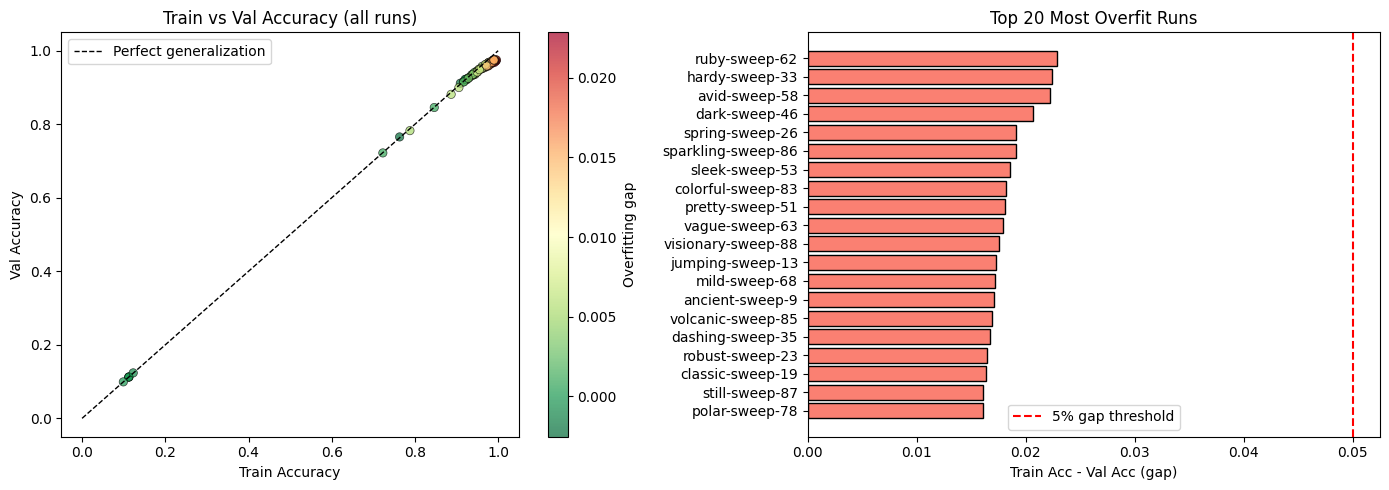

✅ Q2.7 done!


In [21]:
# Q2.7 - Training vs Test Accuracy across all sweep runs
# Fetches all runs from your sweep and plots train vs test accuracy

import wandb

api = wandb.Api()

# fetch all runs from your project
runs = api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}" if WANDB_ENTITY else WANDB_PROJECT)

train_accs = []
val_accs   = []
run_names  = []

for run in runs:
    # only grab completed runs that have both metrics
    if run.state == "finished":
        summary = run.summary
        if "train_acc" in summary and "val_acc" in summary:
            train_accs.append(summary["train_acc"])
            val_accs.append(summary["val_acc"])
            run_names.append(run.name)

train_accs = np.array(train_accs)
val_accs   = np.array(val_accs)
gap        = train_accs - val_accs

print(f"Total runs fetched: {len(train_accs)}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter: train acc vs val acc
sc = axes[0].scatter(train_accs, val_accs, c=gap, cmap="RdYlGn_r",
                     alpha=0.7, edgecolors="black", linewidths=0.5)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect generalization")
axes[0].set_xlabel("Train Accuracy")
axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Train vs Val Accuracy (all runs)")
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label="Overfitting gap")

# bar: overfitting gap per run (top 20 by gap)
top_idx  = np.argsort(gap)[-20:]
axes[1].barh(
    [run_names[i][:20] for i in top_idx],
    gap[top_idx],
    color="salmon", edgecolor="black"
)
axes[1].set_xlabel("Train Acc - Val Acc (gap)")
axes[1].set_title("Top 20 Most Overfit Runs")
axes[1].axvline(x=0.05, color="red", linestyle="--", label="5% gap threshold")
axes[1].legend()

plt.tight_layout()

# log to W&B
run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = "q2_7_global_performance",
)
wandb.log({"global_performance": wandb.Image(fig)})
wandb.finish()

plt.show()
print("✅ Q2.7 done!")

Total runs fetched: 99


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


✅ Q2.7 done!


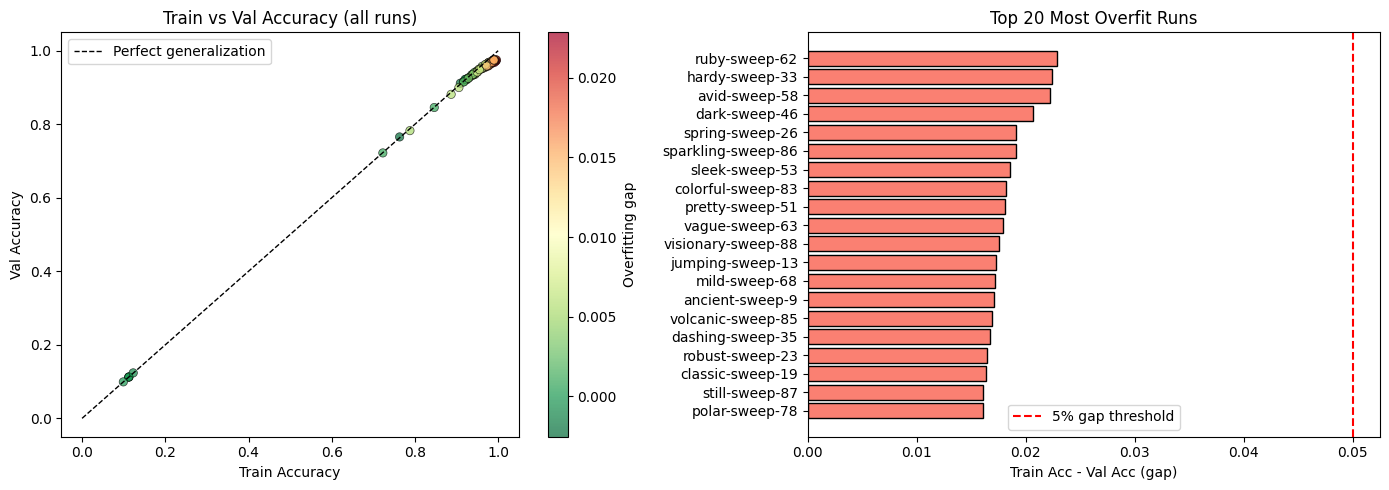

In [13]:
# Q2.7 - Training vs Test Accuracy across all sweep runs
# Fetches all runs from your sweep and plots train vs test accuracy

import wandb

api = wandb.Api()

# fetch all runs from your project
runs = api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}" if WANDB_ENTITY else WANDB_PROJECT)

train_accs = []
val_accs   = []
run_names  = []

for run in runs:
    # only grab completed runs that have both metrics
    if run.state == "finished":
        summary = run.summary
        if "train_acc" in summary and "val_acc" in summary:
            train_accs.append(summary["train_acc"])
            val_accs.append(summary["val_acc"])
            run_names.append(run.name)

train_accs = np.array(train_accs)
val_accs   = np.array(val_accs)
gap        = train_accs - val_accs

print(f"Total runs fetched: {len(train_accs)}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter: train acc vs val acc
sc = axes[0].scatter(train_accs, val_accs, c=gap, cmap="RdYlGn_r",
                     alpha=0.7, edgecolors="black", linewidths=0.5)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect generalization")
axes[0].set_xlabel("Train Accuracy")
axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Train vs Val Accuracy (all runs)")
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label="Overfitting gap")

# bar: overfitting gap per run (top 20 by gap)
top_idx  = np.argsort(gap)[-20:]
axes[1].barh(
    [run_names[i][:20] for i in top_idx],
    gap[top_idx],
    color="salmon", edgecolor="black"
)
axes[1].set_xlabel("Train Acc - Val Acc (gap)")
axes[1].set_title("Top 20 Most Overfit Runs")
axes[1].axvline(x=0.05, color="red", linestyle="--", label="5% gap threshold")
axes[1].legend()

plt.tight_layout()

# log to W&B

run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = "q2_7_global_performance"
)

wandb.log({"Train_vs_Val_Accuracy": wandb.Image(fig)})

run.finish()
print("✅ Q2.7 done!")

[Model] Loaded ← ../src/models/best_model.npy


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


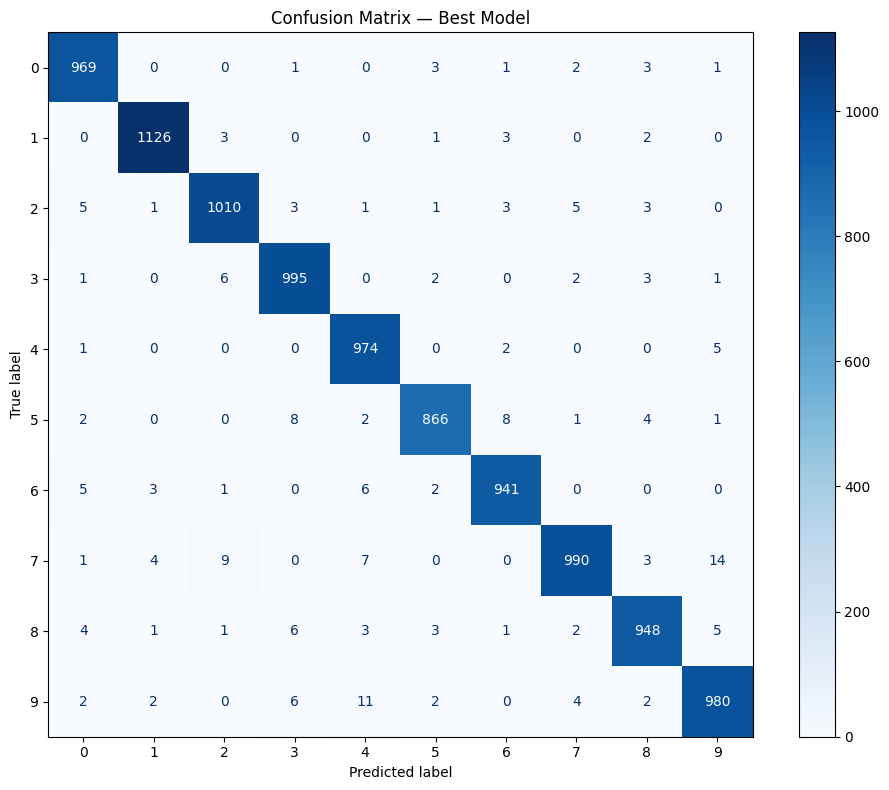

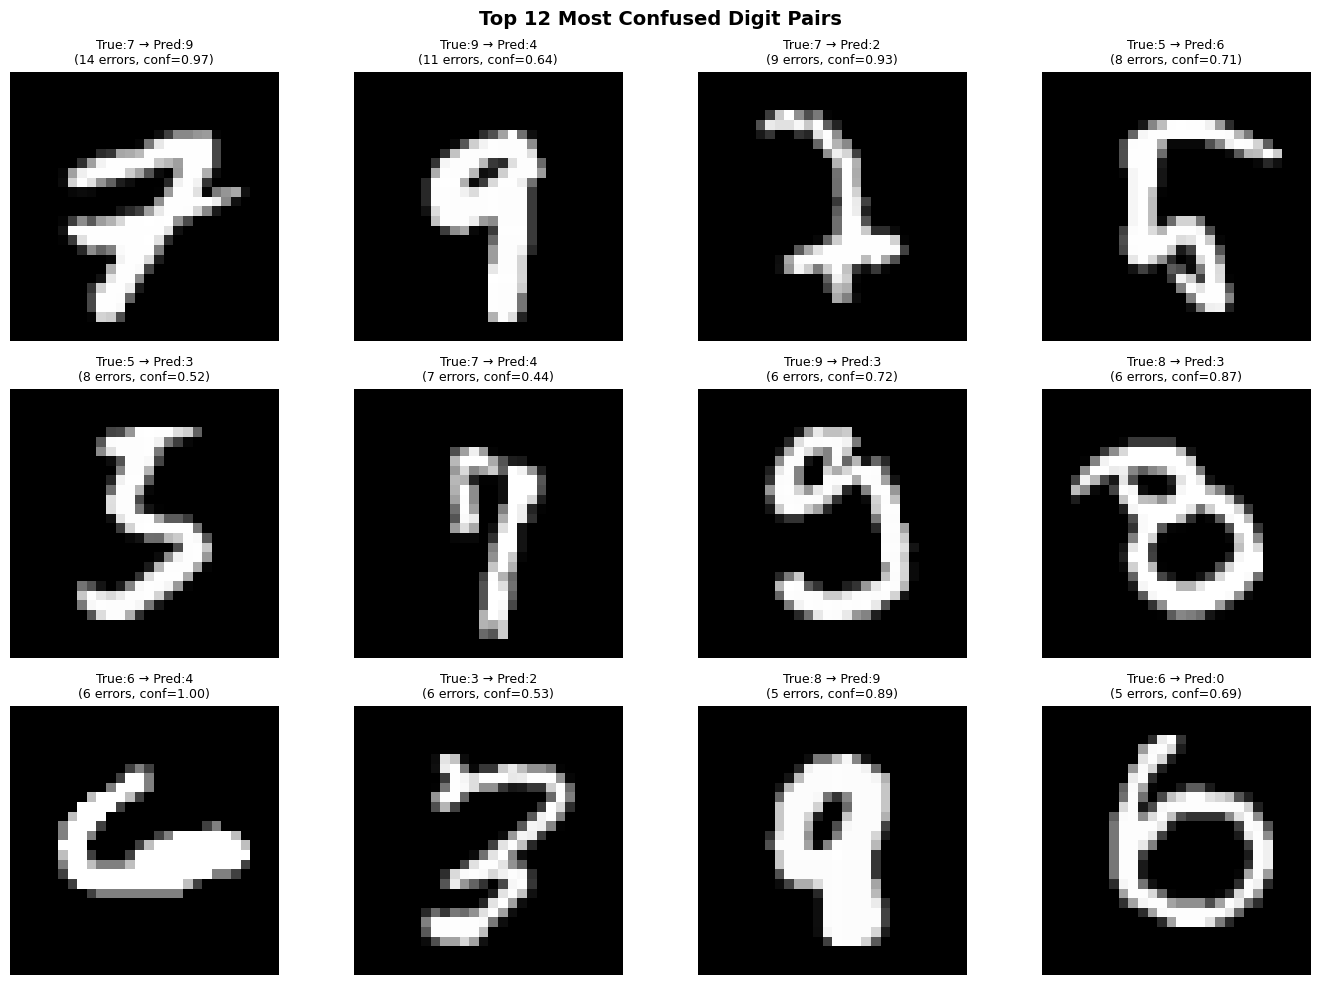

✅ Q2.8 done!


In [14]:
# Q2.8 - Confusion Matrix for best model + creative error visualization
import json
import argparse

# ── load best model ────────────────────────────────────────────────────────────
with open("../src/models/best_config.json") as f:
    cfg = json.load(f)


args = argparse.Namespace(
    hidden_size   = cfg["hidden_sizes"],
    num_layers    = len(cfg["hidden_sizes"]),
    activation    = cfg["activation"],
    weight_init   = cfg["weight_init"],
    loss          = cfg["loss"],
    optimizer     = "adam",
    learning_rate = 0.001,
    weight_decay  = 0.0,
    batch_size    = 64,
    epochs        = 10,
    dataset       = "mnist",
    wandb_project = WANDB_PROJECT,
    wandb_entity  = WANDB_ENTITY,
    no_wandb      = True,
    val_split     = 0.1,
    seed          = 42,
    save_dir      = "models",
)

best_model = NeuralNetwork(args)
best_model.load("../src/models/best_model.npy")

# ── predictions ───────────────────────────────────────────────────────────────
probs      = best_model.predict_proba(X_test)
y_pred_int = np.argmax(probs,   axis=1)
y_true_int = np.argmax(y_test,  axis=1)

CLASS_NAMES = [str(i) for i in range(10)]

# ── confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true_int, y_pred_int)

fig1, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Best Model")
plt.tight_layout()

# ── creative error visualization — show worst confused pairs ──────────────────
# find most confused pairs (off-diagonal with highest counts)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

fig2, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

# get top 12 most confused pairs
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((cm_no_diag[i, j], i, j))

confused_pairs.sort(reverse=True)
top_pairs = confused_pairs[:12]

from tensorflow.keras.datasets import mnist
(X_raw, y_raw), (X_te_raw, y_te_raw) = mnist.load_data()

for ax_idx, (count, true_cls, pred_cls) in enumerate(top_pairs):
    # find a misclassified example
    mask = (y_true_int == true_cls) & (y_pred_int == pred_cls)
    idxs = np.where(mask)[0]

    if len(idxs) > 0:
        img_idx    = idxs[0]
        confidence = probs[img_idx, pred_cls]

        axes[ax_idx].imshow(X_te_raw[img_idx], cmap="gray")
        axes[ax_idx].set_title(
            f"True:{true_cls} → Pred:{pred_cls}\n"
            f"({count} errors, conf={confidence:.2f})",
            fontsize=9
        )
    axes[ax_idx].axis("off")

fig2.suptitle("Top 12 Most Confused Digit Pairs", fontsize=14, fontweight="bold")
plt.tight_layout()

# ── log to W&B ────────────────────────────────────────────────────────────────
run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = "q2_8_error_analysis",
)

wandb.log({
    "confusion_matrix"  : wandb.Image(fig1),
    "error_analysis"    : wandb.Image(fig2),
})

# also log as W&B confusion matrix (interactive)
wandb.log({
    "interactive_cm": wandb.plot.confusion_matrix(
        probs        = None,
        y_true       = y_true_int.tolist(),
        preds        = y_pred_int.tolist(),
        class_names  = CLASS_NAMES,
    )
})

wandb.finish()

plt.show()
print("✅ Q2.8 done!")

In [15]:
# Q2.9 - Zeros vs Xavier initialization
# Track gradients of 5 neurons in the same hidden layer
# over first 50 training iterations

NEURON_IDXS = [0, 1, 2, 3, 4]   # 5 neurons to track in layer 0
MAX_ITER    = 50                  # first 50 iterations only

INIT_CONFIGS = [
    {"name": "zeros_init",  "weight_init": "zeros"},
    {"name": "xavier_init", "weight_init": "xavier"},
]

for cfg in INIT_CONFIGS:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f"q2_9_{cfg['name']}",
        group   = "q2_9_weight_init",
    )

    args = argparse.Namespace(
        hidden_size   = [64],
        num_layers    = 2,
        activation    = "sigmoid",
        weight_init   = cfg["weight_init"],
        loss          = "cross_entropy",
        optimizer     = "adam",
        learning_rate = 0.001,
        weight_decay  = 0.0,
        batch_size    = 64,
        epochs        = 10,
        dataset       = "mnist",
        wandb_project = WANDB_PROJECT,
        wandb_entity  = WANDB_ENTITY,
        no_wandb      = True,
        val_split     = 0.1,
        seed          = 42,
        save_dir      = "models",
    )

    model = NeuralNetwork(args)

    # manually zero out weights for zeros experiment
    if cfg["weight_init"] == "zeros":
        for layer in model.layers:
            layer.W[:] = 0.0
            layer.b[:] = 0.0

    optimizer = get_optimizer("adam", lr=0.001)
    step      = 0

    for X_batch, y_batch in get_batches(X_train, y_train, 64):
        if step >= MAX_ITER:
            break

        y_pred = model.forward(X_batch)
        model.backward(y_batch, y_pred)
        model.update_weights(optimizer)

        # log gradient norm for each of the 5 tracked neurons
        log_dict = {"step": step}
        for ni in NEURON_IDXS:
            grad_norm_ni = float(np.linalg.norm(model.layers[0].grad_W[:, ni]))
            log_dict[f"neuron_{ni}_grad_norm"] = grad_norm_ni

        wandb.log(log_dict, step=step)

        if step % 10 == 0:
            print(f"[{cfg['name']}] Step {step}/{MAX_ITER}  "
                  f"neuron_0_grad={log_dict['neuron_0_grad_norm']:.6f}")

        step += 1

    wandb.finish()
    print(f"✅ {cfg['name']} done!\n")

print("✅ Q2.9 done!")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[zeros_init] Step 0/50  neuron_0_grad=0.000000
[zeros_init] Step 10/50  neuron_0_grad=0.000079
[zeros_init] Step 20/50  neuron_0_grad=0.000440
[zeros_init] Step 30/50  neuron_0_grad=0.000267
[zeros_init] Step 40/50  neuron_0_grad=0.000243


neuron_0_grad_norm,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▅▄▄▄▅▄▄▄▅▆▃▄▄▅▆▄▃▆▅▅█▄▅▆
neuron_1_grad_norm,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▅▄▄▄▅▄▄▄▅▆▃▄▅▄▆▄▃▆▅▅█▄▅▆
neuron_2_grad_norm,▁▁▁▁▁▁▂▂▂▂▃▂▂▃▃▄▃▅▄▄▄▅▄▄▅▆▃▄▅▄▆▄▃▆▅▅█▄▅▆
neuron_3_grad_norm,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▅▄▆▄▅▅▆▅▅▆█▄▆▅▆▅▇▅▄▇▅▇▅▆█
neuron_4_grad_norm,▁▁▁▁▁▁▂▂▂▂▃▂▃▃▃▃▅▄▄▄▅▄▄▄▅▆▃▄▄▅▄▆▄▃▅▅█▄▅▆
step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,0.00058
neuron_1_grad_norm,0.00058
neuron_2_grad_norm,0.00058
neuron_3_grad_norm,0.00058
neuron_4_grad_norm,0.00058


✅ zeros_init done!



wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[xavier_init] Step 0/50  neuron_0_grad=0.021798
[xavier_init] Step 10/50  neuron_0_grad=0.012612
[xavier_init] Step 20/50  neuron_0_grad=0.020188
[xavier_init] Step 30/50  neuron_0_grad=0.018382
[xavier_init] Step 40/50  neuron_0_grad=0.011573


neuron_0_grad_norm,▅▃▂▃▂▃▆▂▃▂▃▃▃█▅▁▄▄▃▃▁▂▃▂▄▂▄▂▂▃▃▁▂▂▁▃▂▂▂▃
neuron_1_grad_norm,█▃▅▃▁▃▃▂▄▃▃▂▂▃▃▁▂▂▄▂▁▁▃▁▁▂▄▂▃▂▁▇▂▁▃▃▂▂▃▅
neuron_2_grad_norm,█▂▄▅▁▃▃▂▅▃▃▁▃▂▂▃▂▄▃▂▄▄▃▂▇▆▁▇▄▃▄▃▂▂▂▃▂▃▃▄
neuron_3_grad_norm,▆▄▇▇▄█▂▄▁▂▃▂▅▃▅▇▂▃▇▂▂▆▃▁▇▃▄▃▃▃▃█▁▄▂▂▃▁▄▄
neuron_4_grad_norm,▅▂▂▅▂▅▄▃▃▃▂▇▃▂▄▃▃▃▂▃▄▂▅▁▅▆▂▅▂▃▃▇▂▁▁▃▁▂▃█
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
neuron_0_grad_norm,0.01414
neuron_1_grad_norm,0.01507
neuron_2_grad_norm,0.0101
neuron_3_grad_norm,0.01663
neuron_4_grad_norm,0.03064


✅ xavier_init done!

✅ Q2.9 done!


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[config_A_adam_relu] Epoch 1/15  loss=0.5217  val_acc=0.8580
[config_A_adam_relu] Epoch 2/15  loss=0.3748  val_acc=0.8698
[config_A_adam_relu] Epoch 3/15  loss=0.3351  val_acc=0.8783
[config_A_adam_relu] Epoch 4/15  loss=0.3152  val_acc=0.8762
[config_A_adam_relu] Epoch 5/15  loss=0.2954  val_acc=0.8707
[config_A_adam_relu] Epoch 6/15  loss=0.2818  val_acc=0.8918
[config_A_adam_relu] Epoch 7/15  loss=0.2660  val_acc=0.8880
[config_A_adam_relu] Epoch 8/15  loss=0.2574  val_acc=0.8940
[config_A_adam_relu] Epoch 9/15  loss=0.2444  val_acc=0.8910
[config_A_adam_relu] Epoch 10/15  loss=0.2362  val_acc=0.8925
[config_A_adam_relu] Epoch 11/15  loss=0.2252  val_acc=0.8985
[config_A_adam_relu] Epoch 12/15  loss=0.2193  val_acc=0.8972
[config_A_adam_relu] Epoch 13/15  loss=0.2116  val_acc=0.8960
[config_A_adam_relu] Epoch 14/15  loss=0.2038  val_acc=0.9015
[config_A_adam_relu] Epoch 15/15  loss=0.1957  val_acc=0.8967


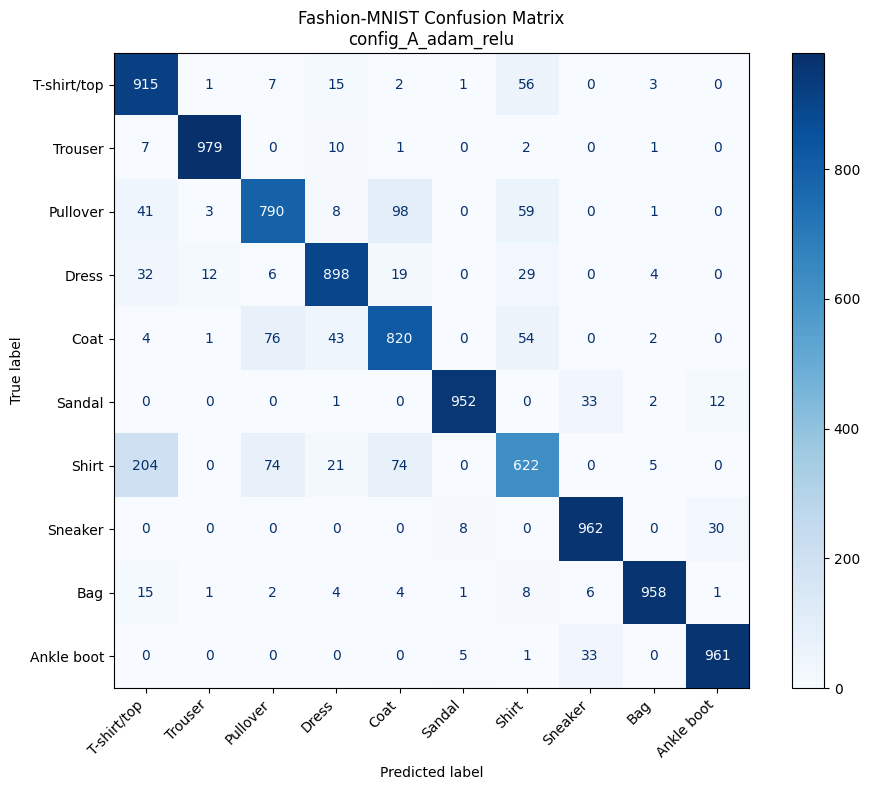

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



[config_A_adam_relu] TEST ACC = 0.8857



best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▃▄▄▃▆▆▇▆▇█▇▇█▇
best_val_acc,0.9015
epoch,15
test_acc,0.8857
train_loss,0.19566
val_acc,0.89667


[config_B_nadam_relu] Epoch 1/15  loss=0.4922  val_acc=0.8688
[config_B_nadam_relu] Epoch 2/15  loss=0.3615  val_acc=0.8827
[config_B_nadam_relu] Epoch 3/15  loss=0.3289  val_acc=0.8657
[config_B_nadam_relu] Epoch 4/15  loss=0.3060  val_acc=0.8858
[config_B_nadam_relu] Epoch 5/15  loss=0.2907  val_acc=0.8845
[config_B_nadam_relu] Epoch 6/15  loss=0.2762  val_acc=0.8757
[config_B_nadam_relu] Epoch 7/15  loss=0.2646  val_acc=0.8933
[config_B_nadam_relu] Epoch 8/15  loss=0.2532  val_acc=0.8918
[config_B_nadam_relu] Epoch 9/15  loss=0.2452  val_acc=0.8977
[config_B_nadam_relu] Epoch 10/15  loss=0.2342  val_acc=0.8957
[config_B_nadam_relu] Epoch 11/15  loss=0.2288  val_acc=0.8918
[config_B_nadam_relu] Epoch 12/15  loss=0.2199  val_acc=0.8960
[config_B_nadam_relu] Epoch 13/15  loss=0.2146  val_acc=0.8965
[config_B_nadam_relu] Epoch 14/15  loss=0.2038  val_acc=0.8953
[config_B_nadam_relu] Epoch 15/15  loss=0.1960  val_acc=0.9022


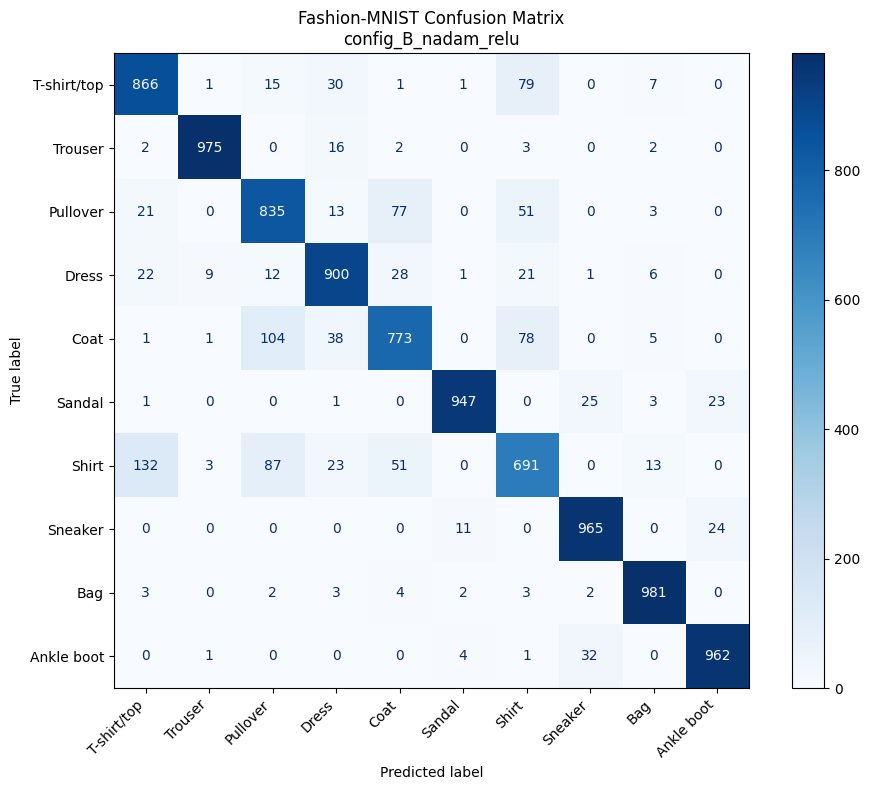

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



[config_B_nadam_relu] TEST ACC = 0.8895



best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁
val_acc,▂▄▁▅▅▃▆▆▇▇▆▇▇▇█
best_val_acc,0.90217
epoch,15
test_acc,0.8895
train_loss,0.19601
val_acc,0.90217


[config_C_adam_tanh] Epoch 1/15  loss=0.4884  val_acc=0.8710
[config_C_adam_tanh] Epoch 2/15  loss=0.3718  val_acc=0.8750
[config_C_adam_tanh] Epoch 3/15  loss=0.3384  val_acc=0.8692
[config_C_adam_tanh] Epoch 4/15  loss=0.3125  val_acc=0.8798
[config_C_adam_tanh] Epoch 5/15  loss=0.2955  val_acc=0.8805
[config_C_adam_tanh] Epoch 6/15  loss=0.2801  val_acc=0.8942
[config_C_adam_tanh] Epoch 7/15  loss=0.2659  val_acc=0.8907
[config_C_adam_tanh] Epoch 8/15  loss=0.2544  val_acc=0.8833
[config_C_adam_tanh] Epoch 9/15  loss=0.2443  val_acc=0.8900
[config_C_adam_tanh] Epoch 10/15  loss=0.2345  val_acc=0.8997
[config_C_adam_tanh] Epoch 11/15  loss=0.2226  val_acc=0.8968
[config_C_adam_tanh] Epoch 12/15  loss=0.2165  val_acc=0.8918
[config_C_adam_tanh] Epoch 13/15  loss=0.2098  val_acc=0.8973
[config_C_adam_tanh] Epoch 14/15  loss=0.2017  val_acc=0.8988
[config_C_adam_tanh] Epoch 15/15  loss=0.1947  val_acc=0.9030


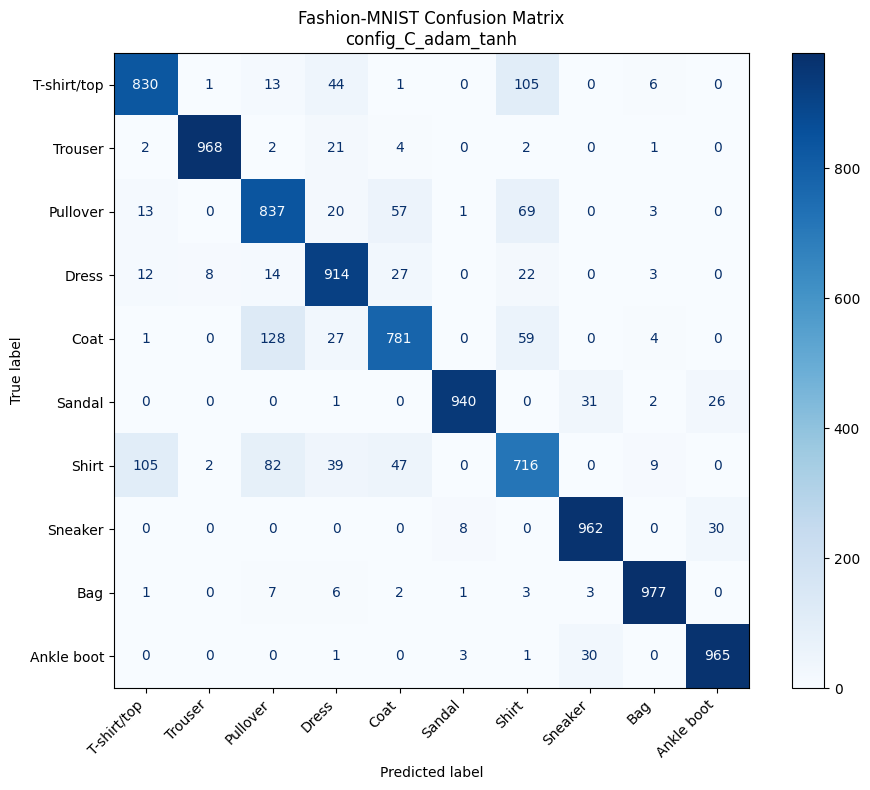

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



[config_C_adam_tanh] TEST ACC = 0.8890



best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▂▁▃▃▆▅▄▅▇▇▆▇▇█
best_val_acc,0.903
epoch,15
test_acc,0.889
train_loss,0.19468
val_acc,0.903


✅ Q2.10 done! All notebook experiments complete!


In [ ]:
# Q2.10 - Fashion-MNIST Transfer Challenge
# Based on MNIST learnings, pick 3 best configs and test on Fashion-MNIST

# load Fashion-MNIST
X_tr_f, y_tr_f, X_val_f, y_val_f, X_te_f, y_te_f = load_dataset("fashion_mnist")

FASHION_CLASSES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress",    "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",       "Ankle boot"
]

# 3 configs chosen based on MNIST sweep findings
CONFIGS = [
    {
        "name"        : "config_A_adam_relu",
        "hidden_sizes": [128, 128, 128],
        "activation"  : "relu",
        "optimizer"   : "adam",
        "lr"          : 0.001,
        "description" : "Best MNIST config — adam + relu + 3 layers",
    },
    {
        "name"        : "config_B_nadam_relu",
        "hidden_sizes": [128, 128, 128, 128],
        "activation"  : "relu",
        "optimizer"   : "nadam",
        "lr"          : 0.001,
        "description" : "Deeper network — nadam + relu + 4 layers",
    },
    {
        "name"        : "config_C_adam_tanh",
        "hidden_sizes": [128, 128, 128],
        "activation"  : "tanh",
        "optimizer"   : "adam",
        "lr"          : 0.001,
        "description" : "Tanh variant — adam + tanh + 3 layers",
    },
]

EPOCHS = 15

for cfg in CONFIGS:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f"q2_10_{cfg['name']}",
        group   = "q2_10_fashion_transfer",
        config  = cfg,
    )


    args = argparse.Namespace(
        hidden_size   = cfg["hidden_sizes"],
        num_layers    = len(cfg["hidden_sizes"]),
        activation    = cfg["activation"],
        weight_init   = "xavier",
        loss          = "cross_entropy",
        optimizer     = cfg["optimizer"],
        learning_rate = cfg["lr"],
        weight_decay  = 0.0,
        batch_size    = 64,
        epochs        = EPOCHS,
        dataset       = "fashion_mnist",
        wandb_project = WANDB_PROJECT,
        wandb_entity  = WANDB_ENTITY,
        no_wandb      = True,
        val_split     = 0.1,
        seed          = 42,
        save_dir      = "models",
    )

    model = NeuralNetwork(args)

    optimizer = get_optimizer(cfg["optimizer"], lr=cfg["lr"])

    best_val_acc = 0.0

    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in get_batches(X_tr_f, y_tr_f, 64):
            y_pred = model.forward(X_batch)
            epoch_loss += model.compute_loss(y_pred, y_batch)
            model.backward(y_batch, y_pred)
            model.update_weights(optimizer)
            n_batches += 1

        train_loss = epoch_loss / n_batches
        val_acc    = model.evaluate(X_val_f, y_val_f)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        wandb.log({
            "epoch"      : epoch,
            "train_loss" : train_loss,
            "val_acc"    : val_acc,
        }, step=epoch)

        print(f"[{cfg['name']}] Epoch {epoch}/{EPOCHS}  "
              f"loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    # ── final test accuracy ────────────────────────────────────────────────────
    test_acc   = model.evaluate(X_te_f, y_te_f)
    test_probs = model.predict_proba(X_te_f)
    y_pred_int = np.argmax(test_probs,  axis=1)
    y_true_int = np.argmax(y_te_f,      axis=1)

    # confusion matrix for fashion
    cm   = confusion_matrix(y_true_int, y_pred_int)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=FASHION_CLASSES)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(f"Fashion-MNIST Confusion Matrix\n{cfg['name']}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    wandb.log({
        "test_acc"        : test_acc,
        "best_val_acc"    : best_val_acc,
        "confusion_matrix": wandb.Image(fig),
    })

    plt.show()
    print(f"\n[{cfg['name']}] TEST ACC = {test_acc:.4f}\n")

    wandb.finish()

print("✅ Q2.10 done! All notebook experiments complete!")

# Demo code starts from here

In [12]:

def visualize_data(X, y, save_path=None):
    """
    Visualize the synthetic dataset

    In your assignment, this would be like visualizing MNIST digits
    (Question 2.1 - log sample images from each class)
    """
    fig = plt.figure(figsize=(15, 10))

    # 1. Feature distributions
    ax1 = plt.subplot(2, 3, 1)
    for i in range(min(5, X.shape[1])):
        ax1.hist(X[:, i], bins=30, alpha=0.5, label=f'Feature {i+1}')
    ax1.set_xlabel('Feature Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Feature Distributions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Target distribution
    ax2 = plt.subplot(2, 3, 2)
    ax2.hist(y, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Target Value')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Target Distribution')
    ax2.grid(True, alpha=0.3)

    # 3. Feature correlation with target
    ax3 = plt.subplot(2, 3, 3)
    correlations = [np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])]
    ax3.bar(range(len(correlations)), correlations, color='coral', edgecolor='black')
    ax3.set_xlabel('Feature Index')
    ax3.set_ylabel('Correlation with Target')
    ax3.set_title('Feature Importance (Correlation)')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)

    # 4. Scatter plot - Feature 1 vs Target
    ax4 = plt.subplot(2, 3, 4)
    scatter = ax4.scatter(X[:, 0], y, alpha=0.5, c=y, cmap='viridis', s=20)
    ax4.set_xlabel('Feature 1')
    ax4.set_ylabel('Target')
    ax4.set_title('Feature 1 vs Target')
    plt.colorbar(scatter, ax=ax4, label='Target Value')
    ax4.grid(True, alpha=0.3)

    # 5. Feature pairwise relationship
    ax5 = plt.subplot(2, 3, 5)
    scatter2 = ax5.scatter(X[:, 0], X[:, 1], c=y, cmap='plasma', alpha=0.6, s=20)
    ax5.set_xlabel('Feature 1')
    ax5.set_ylabel('Feature 2')
    ax5.set_title('Feature 1 vs Feature 2 (colored by target)')
    plt.colorbar(scatter2, ax=ax5, label='Target')
    ax5.grid(True, alpha=0.3)

    # 6. Summary statistics
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    stats_text = f"""
    Dataset Statistics:
    ━━━━━━━━━━━━━━━━━━━━━━━
    Samples: {X.shape[0]}
    Features: {X.shape[1]}

    Target Statistics:
    • Mean: {np.mean(y):.2f}
    • Std: {np.std(y):.2f}
    • Min: {np.min(y):.2f}
    • Max: {np.max(y):.2f}

    Feature Statistics:
    • Mean: {np.mean(X):.3f}
    • Std: {np.std(X):.3f}
    """
    ax6.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
             verticalalignment='center')

    plt.suptitle('Synthetic Data Visualization', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig

## Linear Regression code

In [13]:

class LinearRegression:
    """
    Linear Regression with NumPy

    """

    def __init__(self, n_features, learning_rate=0.01, weight_init='random',
                 weight_decay=0.0):
        self.lr = learning_rate
        self.weight_init = weight_init
        self.weight_decay = weight_decay

        # Initialize weights
        if weight_init == 'zero':
            self.W = np.zeros((n_features, 1))
            self.b = 0.0
        elif weight_init == 'random':
            self.W = np.random.randn(n_features, 1) * 0.01
            self.b = 0.0
        elif weight_init == 'xavier':
            self.W = np.random.randn(n_features, 1) * np.sqrt(2.0 / n_features)
            self.b = 0.0

        # Gradient storage (required for autograder verification)
        self.grad_W = None
        self.grad_b = None

    def forward(self, X):
        """Forward pass"""
        return X @ self.W + self.b

    def compute_loss(self, y_true, y_pred, loss_type='mse'):
        """
        Compute loss based on type

        """
        if loss_type == 'mse':
            loss = np.mean((y_true - y_pred) ** 2)
        elif loss_type == 'mae':
            loss = np.mean(np.abs(y_true - y_pred))
        else:
            raise ValueError(f"Unknown loss: {loss_type}")

        # Add L2 regularization
        if self.weight_decay > 0:
            l2_penalty = 0.5 * self.weight_decay * np.sum(self.W ** 2)
            loss += l2_penalty

        return loss

    def backward(self, X, y_true, y_pred, loss_type='mse'):
        """
        Compute gradients

        """
        m = X.shape[0]

        if loss_type == 'mse':
            error = y_pred - y_true
        elif loss_type == 'mae':
            error = np.sign(y_pred - y_true)

        # Compute gradients
        self.grad_W = (X.T @ error) / m
        self.grad_b = np.mean(error)

        # Add L2 regularization gradient
        if self.weight_decay > 0:
            self.grad_W += self.weight_decay * self.W

        return self.grad_W, self.grad_b

    def update_weights(self):
        """Update weights using gradient descent"""
        self.W -= self.lr * self.grad_W
        self.b -= self.lr * self.grad_b

    def predict(self, X):
        """Make predictions"""
        return self.forward(X)

## Training

In [11]:
def train_with_wandb(config=None, exp_name='base'):
    """
    Complete training loop with W&B logging

    """

    #================KEY STEP====================
    wandb.init(project=PROJECT_NAME, name=exp_name)

    print("Generating synthetic data...")
    X, y, true_weights = create_synthetic_data(
            n_samples=1000,
            n_features=10,
            noise_level=15
    )
    y = y.reshape(-1, 1)

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42)

    # Normalize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Initialize model
    model = LinearRegression(
            n_features=X_train.shape[1],
            learning_rate=config["learning_rate"],
            weight_init=config["weight_init"])

    # Training metrics storage
    train_losses = []
    val_losses = []
    gradient_norms = []
    weight_norms = []

    print(f"\n{'='*60}")
    print(f"Training Configuration:")
    print(f"  Loss: {config["loss_type"]}")
    print(f"  Init: {config["weight_init"]}")
    print(f"  LR: {config["learning_rate"]}")
    print(f"  Epochs: {config["epochs"]}")
    print(f"{'='*60}\n")

    # Training loop
    for epoch in range(config["epochs"]):
        # Forward pass
        y_pred_train = model.forward(X_train)
        train_loss = model.compute_loss(y_train, y_pred_train, config["loss_type"])

        # Backward pass
        model.backward(X_train, y_train, y_pred_train, config["loss_type"])

        # Track metrics
        grad_norm = np.linalg.norm(model.grad_W)
        weight_norm = np.linalg.norm(model.W)

        gradient_norms.append(grad_norm)
        weight_norms.append(weight_norm)

        # Update weights
        model.update_weights()

        # Validation
        y_pred_val = model.forward(X_val)
        val_loss = model.compute_loss(y_val, y_pred_val, config["loss_type"])

        # Store losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Calculate R² score (for regression evaluation)
        ss_res = np.sum((y_val - y_pred_val) ** 2)
        ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
        r2_score = 1 - (ss_res / ss_tot)

        # === KEY STEP: LOG TO W&B ===
        wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'gradient_norm': grad_norm,
                'weight_norm': weight_norm,
                'r2_score': r2_score,
                'overfitting_gap': train_loss - val_loss,})

        # Print progress
        if epoch % 20 == 0 or epoch == config["epochs"] - 1:
            print(f"Epoch {epoch:3d}: Train Loss = {train_loss:.4f}, "
                      f"Val Loss = {val_loss:.4f}, R² = {r2_score:.4f}")

    # === LOG FINAL METRICS ===
    final_metrics = {
            'final_train_loss': train_losses[-1],
            'final_val_loss': val_losses[-1],
            'final_r2': r2_score,
            'best_val_loss': min(val_losses),
            'convergence_epoch': np.argmin(val_losses),
        }
    wandb.log(final_metrics)


    # === LOG PREDICTION SCATTER PLOT ===
    # pred_fig = create_prediction_plot(y_val, y_pred_val)
    # wandb.log({"predictions": wandb.Image(pred_fig)})
    # plt.close(pred_fig)

    wandb.finish()
    print(f"\n✓ Training completed!")
    print(f"  Final Val Loss: {val_losses[-1]:.4f}")
    print(f"  Final R²: {r2_score:.4f}")

    return val_losses[-1]

## DEMO 1: Basic W&B Logging (Single Run)

In [7]:
def data_visualization():
    """
    DEMO 1: Visualize the synthetic data
    This is like Question 2.1 in your assignment
    """
    print("\n" + "="*70)
    print("DEMO 1: Data Visualization")
    print("="*70)

    # Generate data
    X, y, true_weights = create_synthetic_data()

    # Create visualization
    fig = visualize_data(X, y)

    # Log to W&B
    #=========KEY STEP=================
    wandb.init(project=PROJECT_NAME, name="data_viz")

    wandb.log({
        "data_visualization": wandb.Image(fig),
        "n_samples": X.shape[0],
        "n_features": X.shape[1]
    })

    # Also create a W&B table
    table = wandb.Table(columns=["Sample ID", "Feature 1", "Feature 2", "Target"])
    for i in range(20):  # Show first 20 samples
        table.add_data(i, X[i, 0], X[i, 1], y[i])

    wandb.log({"sample_data": table})

    plt.savefig('/tmp/data_viz.png', dpi=150, bbox_inches='tight')
    plt.show()

    wandb.finish()

    print("\n✓ Data visualization logged to W&B!")
    print("  Check your dashboard for the visualization and data table")




DEMO 1: Data Visualization


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: da24s004 (da24s004-iitm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


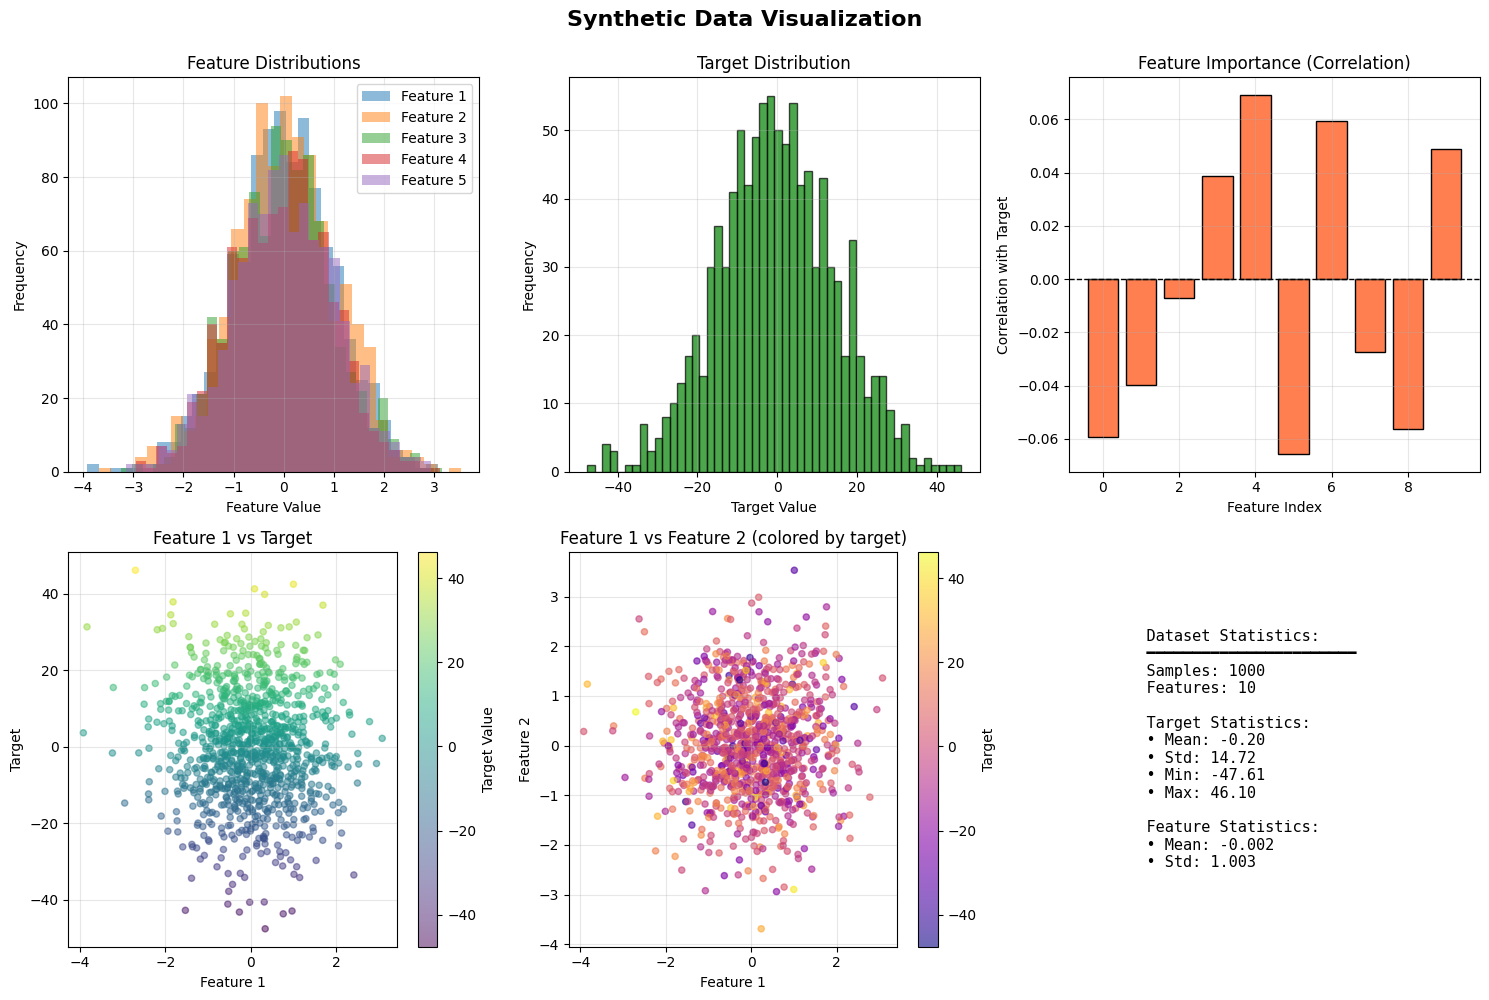

n_features,▁
n_samples,▁
n_features,10
n_samples,1000



✓ Data visualization logged to W&B!
  Check your dashboard for the visualization and data table


In [8]:
data_visualization()

## Demo 2: Training with wandb logging

In [9]:
def training():
    """
    DEMO 2: Train a single model with W&B logging
    """
    print("\n" + "="*70)
    print("DEMO 2: Single Training Run")
    print("="*70)

    config = {
        'learning_rate': 0.001,
        'epochs': 100,
        'loss_type': 'mse',
        'weight_init': 'random'
    }

    train_with_wandb(config, exp_name='initial_training with new lr')

    print("\n✓ Training completed and logged to W&B!")

In [10]:
training()


DEMO 2: Single Training Run


Generating synthetic data...

Training Configuration:
  Loss: mse
  Init: random
  LR: 0.001
  Epochs: 100

Epoch   0: Train Loss = 217.0877, Val Loss = 214.9517, R² = -0.0102
Epoch  20: Train Loss = 216.8975, Val Loss = 214.7864, R² = -0.0095
Epoch  40: Train Loss = 216.7148, Val Loss = 214.6278, R² = -0.0087
Epoch  60: Train Loss = 216.5392, Val Loss = 214.4756, R² = -0.0080
Epoch  80: Train Loss = 216.3706, Val Loss = 214.3296, R² = -0.0073
Epoch  99: Train Loss = 216.2165, Val Loss = 214.1965, R² = -0.0067

✓ Training completed!
  Final Val Loss: 214.1965
  Final R²: -0.0067

✓ Training completed and logged to W&B!


## Demo 3: Loss and init Comparison

In [12]:
def loss_comparison():
    """
    DEMO 3: Compare MSE vs MAE loss functions
    This is like Question 2.6 in your assignment (MSE vs Cross-Entropy)
    """
    print("\n" + "="*70)
    print("DEMO 3: Loss Function Comparison (MSE vs MAE)")
    print("="*70)

    configs = [
        {'learning_rate': 0.01, 'epochs': 100, 'loss_type': 'mse','weight_init': 'random'},
        {'learning_rate': 0.01, 'epochs': 100, 'loss_type': 'mae', 'weight_init': 'random'},
    ]

    for cfg in configs:
        print(f"\nTraining with {cfg['loss_type'].upper()} loss...")
        train_with_wandb(cfg, exp_name=f"loss_comparison_with_{cfg['loss_type'].upper()}")

    print("\n✓ Loss comparison completed!")
    print("  Go to W&B dashboard and compare the two runs side-by-side")
    print("  Key question: Which loss converged faster?")

In [13]:
loss_comparison()


DEMO 3: Loss Function Comparison (MSE vs MAE)

Training with MSE loss...


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,████▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
overfitting_gap,█████▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
r2_score,▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇██
train_loss,███▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁
+2,...


Generating synthetic data...

Training Configuration:
  Loss: mse
  Init: random
  LR: 0.01
  Epochs: 100

Epoch   0: Train Loss = 217.0877, Val Loss = 214.8761, R² = -0.0099
Epoch  20: Train Loss = 215.4829, Val Loss = 213.5156, R² = -0.0035
Epoch  40: Train Loss = 214.4087, Val Loss = 212.6207, R² = 0.0007
Epoch  60: Train Loss = 213.6889, Val Loss = 212.0349, R² = 0.0035
Epoch  80: Train Loss = 213.2061, Val Loss = 211.6539, R² = 0.0053
Epoch  99: Train Loss = 212.8951, Val Loss = 211.4181, R² = 0.0064


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,████▇▇▇▇▆▆▆▆▆▆▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁
overfitting_gap,█▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
r2_score,▁▁▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,██▇▇▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
+2,...



✓ Training completed!
  Final Val Loss: 211.4181
  Final R²: 0.0064

Training with MAE loss...


Generating synthetic data...

Training Configuration:
  Loss: mae
  Init: random
  LR: 0.01
  Epochs: 100

Epoch   0: Train Loss = 11.6869, Val Loss = 11.6999, R² = -0.0103
Epoch  20: Train Loss = 11.6831, Val Loss = 11.6977, R² = -0.0097
Epoch  40: Train Loss = 11.6795, Val Loss = 11.6955, R² = -0.0092
Epoch  60: Train Loss = 11.6760, Val Loss = 11.6935, R² = -0.0088
Epoch  80: Train Loss = 11.6727, Val Loss = 11.6914, R² = -0.0083
Epoch  99: Train Loss = 11.6695, Val Loss = 11.6895, R² = -0.0079


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,████▆▆▄▄▄▄▄▄▄▄▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfitting_gap,████▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁
r2_score,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
train_loss,█████▇▇▇▇▇▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
+2,...



✓ Training completed!
  Final Val Loss: 11.6895
  Final R²: -0.0079

✓ Loss comparison completed!
  Go to W&B dashboard and compare the two runs side-by-side
  Key question: Which loss converged faster?


In [14]:
def weight_init_comparison():
    """
Compare Zero vs Random initialization
    """
    print("\n" + "="*70)
    print(" Weight Initialization Comparison")
    print("="*70)

    configs = [
        {'learning_rate': 0.01, 'epochs': 100, 'loss_type': 'mse','weight_init': 'zero'},
        {'learning_rate': 0.01, 'epochs': 100, 'loss_type': 'mse','weight_init': 'random'}

    ]

    for cfg in configs:
        print(f"\nTraining with {cfg['weight_init']} initialization...")
        train_with_wandb(cfg, exp_name=f"comparing_weight_init_with_{cfg['weight_init']}")

    print("\n✓ Weight initialization comparison completed!")
    print("  Compare gradient norms across the three runs")
    print("  Zero init should show slower/different convergence")

In [15]:
weight_init_comparison()


DEMO 4: Weight Initialization Comparison

Training with zero initialization...


Generating synthetic data...

Training Configuration:
  Loss: mse
  Init: zero
  LR: 0.01
  Epochs: 100

Epoch   0: Train Loss = 217.1056, Val Loss = 215.0553, R² = -0.0107
Epoch  20: Train Loss = 215.4954, Val Loss = 213.6601, R² = -0.0042
Epoch  40: Train Loss = 214.4174, Val Loss = 212.7376, R² = 0.0002
Epoch  60: Train Loss = 213.6950, Val Loss = 212.1297, R² = 0.0030
Epoch  80: Train Loss = 213.2102, Val Loss = 211.7309, R² = 0.0049
Epoch  99: Train Loss = 212.8981, Val Loss = 211.4815, R² = 0.0061


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
overfitting_gap,███▇▇▇▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
r2_score,▁▁▁▂▂▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,█▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
+2,...



✓ Training completed!
  Final Val Loss: 211.4815
  Final R²: 0.0061

Training with random initialization...


Generating synthetic data...

Training Configuration:
  Loss: mse
  Init: random
  LR: 0.01
  Epochs: 100

Epoch   0: Train Loss = 217.0877, Val Loss = 214.8761, R² = -0.0099
Epoch  20: Train Loss = 215.4829, Val Loss = 213.5156, R² = -0.0035
Epoch  40: Train Loss = 214.4087, Val Loss = 212.6207, R² = 0.0007
Epoch  60: Train Loss = 213.6889, Val Loss = 212.0349, R² = 0.0035
Epoch  80: Train Loss = 213.2061, Val Loss = 211.6539, R² = 0.0053
Epoch  99: Train Loss = 212.8951, Val Loss = 211.4181, R² = 0.0064


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇███
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,██▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
overfitting_gap,██▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
r2_score,▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████████
train_loss,████▇▇▆▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
+2,...



✓ Training completed!
  Final Val Loss: 211.4181
  Final R²: 0.0064

✓ Weight initialization comparison completed!
  Compare gradient norms across the three runs
  Zero init should show slower/different convergence


## Demo 4: Hyperparameter Sweep

In [16]:
def train_with_wandb_for_sweep(config=None):
    """Training function for sweeps or manual configs"""

    #=============KEY STEP=======================
    # ONE init call with 'with' statement
    with wandb.init(project=PROJECT_NAME, config=config):
        # Access config
        cfg = wandb.config

        # Generate data
        print("Generating synthetic data...")
        X, y, true_weights = create_synthetic_data(
            n_samples=1000,
            n_features=10,
            noise_level=15
        )
        y = y.reshape(-1, 1)

        # Split data
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Normalize features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # Initialize model
        model = LinearRegression(
            n_features=X_train.shape[1],
            learning_rate=cfg.learning_rate,
            weight_init=cfg.weight_init
        )

        # Training metrics storage
        train_losses = []
        val_losses = []
        gradient_norms = []
        weight_norms = []

        print(f"\n{'='*60}")
        print(f"Training Configuration:")
        print(f"  Loss: {cfg.loss_type}")
        print(f"  Init: {cfg.weight_init}")
        print(f"  LR: {cfg.learning_rate}")
        print(f"  Epochs: {cfg.epochs}")
        print(f"{'='*60}\n")

        # Training loop
        for epoch in range(cfg.epochs):
            # Forward pass
            y_pred_train = model.forward(X_train)
            train_loss = model.compute_loss(y_train, y_pred_train, cfg.loss_type)

            # Backward pass
            model.backward(X_train, y_train, y_pred_train, cfg.loss_type)

            # Track metrics
            grad_norm = np.linalg.norm(model.grad_W)
            weight_norm = np.linalg.norm(model.W)

            gradient_norms.append(grad_norm)
            weight_norms.append(weight_norm)

            # Update weights
            model.update_weights()

            # Validation
            y_pred_val = model.forward(X_val)
            val_loss = model.compute_loss(y_val, y_pred_val, cfg.loss_type)

            # Store losses
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            # Calculate R² score
            ss_res = np.sum((y_val - y_pred_val) ** 2)
            ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
            r2_score = 1 - (ss_res / ss_tot)

            # === LOG TO W&B ===
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'gradient_norm': grad_norm,
                'weight_norm': weight_norm,
                'r2_score': r2_score,
                'overfitting_gap': train_loss - val_loss,
            })

            # Print progress
            if epoch % 20 == 0 or epoch == cfg.epochs - 1:
                print(f"Epoch {epoch:3d}: Train Loss = {train_loss:.4f}, "
                      f"Val Loss = {val_loss:.4f}, R² = {r2_score:.4f}")

        # === LOG FINAL METRICS ===
        final_metrics = {
            'final_train_loss': train_losses[-1],
            'final_val_loss': val_losses[-1],
            'final_r2': r2_score,
            'best_val_loss': min(val_losses),
            'convergence_epoch': np.argmin(val_losses),
        }
        wandb.log(final_metrics)



        # pred_fig = create_prediction_plot(y_val, y_pred_val)
        # wandb.log({"predictions": wandb.Image(pred_fig)})
        # plt.close(pred_fig)

        print(f"\n✓ Training completed!")
        print(f"  Final Val Loss: {val_losses[-1]:.4f}")
        print(f"  Final R²: {r2_score:.4f}")

        return val_losses[-1]

In [17]:
wandb.finish()

# Define sweep configuration
sweep_config = {
    'method': 'grid',
    'metric': {'name': 'final_test_loss', 'goal': 'minimize'},
    'parameters': {
        'learning_rate': {
            'values': [0.01, 0.05]  # ✅ Only 2 values
        },
        'loss_type': {
            'values': ['mse', 'mae']  # 2 values
        },
        'weight_init': {
            'values': ['random', 'xavier']  # 2 values
        },
        'epochs': {'value': 50}  # ✅ Shorter epochs
    }
}

#================KEY STEP===================
print("Creating sweep...")
sweep_id = wandb.sweep(
    sweep_config,
    project=PROJECT_NAME
)

# Calculate total runs
total_runs = 2 * 2 * 2
print(f"✓ Sweep created: {sweep_id}")
print(f"  Grid search will run {total_runs} experiments")
print("  Starting sweep...")

# Run sweep
wandb.agent(sweep_id, train_with_wandb_for_sweep, count=total_runs)

print("\n✓ Sweep completed!")
print("  Check your W&B dashboard!")

Creating sweep...
Create sweep with ID: oy2wwwug
Sweep URL: https://wandb.ai/da24s004-iitm/Linear_regression_demo/sweeps/oy2wwwug
✓ Sweep created: oy2wwwug
  Grid search will run 8 experiments
  Starting sweep...


wandb: Agent Starting Run: hvzvb01h with config:
wandb: 	epochs: 50
wandb: 	learning_rate: 0.01
wandb: 	loss_type: mse
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Generating synthetic data...

Training Configuration:
  Loss: mse
  Init: random
  LR: 0.01
  Epochs: 50

Epoch   0: Train Loss = 217.0877, Val Loss = 214.8761, R² = -0.0099
Epoch  20: Train Loss = 215.4829, Val Loss = 213.5156, R² = -0.0035
Epoch  40: Train Loss = 214.4087, Val Loss = 212.6207, R² = 0.0007
Epoch  49: Train Loss = 214.0491, Val Loss = 212.3261, R² = 0.0021

✓ Training completed!
  Final Val Loss: 212.3261
  Final R²: 0.0021


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,██▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
overfitting_gap,███▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
r2_score,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
train_loss,███▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
+2,...


wandb: Agent Starting Run: vdqk0gwy with config:
wandb: 	epochs: 50
wandb: 	learning_rate: 0.01
wandb: 	loss_type: mse
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,███▇▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
overfitting_gap,███▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
r2_score,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
+2,...


wandb: Agent Starting Run: sl1qmihk with config:
wandb: 	epochs: 50
wandb: 	learning_rate: 0.05
wandb: 	loss_type: mae
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Generating synthetic data...

Training Configuration:
  Loss: mae
  Init: xavier
  LR: 0.05
  Epochs: 50

Epoch   0: Train Loss = 11.6956, Val Loss = 11.6127, R² = 0.0207
Epoch  20: Train Loss = 11.6788, Val Loss = 11.6077, R² = 0.0212
Epoch  40: Train Loss = 11.6638, Val Loss = 11.6032, R² = 0.0213
Epoch  49: Train Loss = 11.6574, Val Loss = 11.6015, R² = 0.0213

✓ Training completed!
  Final Val Loss: 11.6015
  Final R²: 0.0213


best_val_loss,▁
convergence_epoch,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_r2,▁
final_train_loss,▁
final_val_loss,▁
gradient_norm,███▇▇▇▇▇▇▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfitting_gap,██▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
r2_score,▁▁▂▂▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train_loss,███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
+2,...



✓ Sweep completed!
  Check your W&B dashboard!


## Lets Create the Wandb Report!!